<a href="https://colab.research.google.com/github/AshleyH2026/A03-knn/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?

Regression predicts a numeric value, whereas classification predicts a category or group. A regression would compute the distance of every observed x, selet the k nearest observations, then average their outcomes. A classification would find the k nearest neighbors then estimate each class proportion by dividing neighbor count by k to predict the most common class.


2. What is a confusion table? What does it help us understand about a model's performance?

A confusion table counts predictions by actual class and predicted class. By counting correct predictions and missclassifications, it can help us understand how accurate the model is and where the model is underperforming.

3. What does the SSE quantify about a particular model?

The sum of squared error, which adds squared residuals from validation observations, shows us the amount of error in the validation set. A lower SSE means less error.

4. What are overfitting and underfitting?

Overfitting and underfitting both relate to what predictions the model outputs. Overrfitting means the model's predictions are too detailed and thus more subject to noise in the data (results from a smaller k value). Underfitting means the model's predictions are too broad, to the point where they give nearly the same prediction for every observation or instance (results from a smaller k).

5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?

We split the data into training and testing sets so that we can see how well the model predicts new observations it hasn't seen before. By separating the data it trains on and giving it new data to use for the testing portion, you get a better sense of the model's predictive ability, so it isn't just remembering the correct answer. We can then use the validation data to determine which k to use. The k can improve model performance by avoiding overfitting and underfitting, and finding a good balance between not too much detail (to prevent noise) and enough detail for an accurate prediction. The SSE also helps us determine error with the model so we can further improve the model or consider certain limitationz

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

Just reporting a class label as a prediction can be better for more simplified results that are easier to read or intepret because a prediction must fall into one class label. However, this could result in a loss of nuance and could result in unsure predictions or classifications being displayed as more confident ones. Whereas a prediction or a probability distribution over class labels allows for a more nuanced result, though it may be more difficult to interpret and form conclusions.



**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Ashley Hughes

**Date:** 10/2/2026

1. EDA & summary of target label and features:

Mine Type Historgram



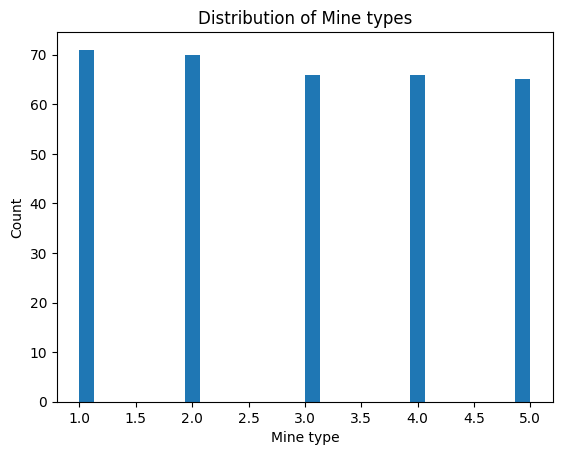

mine_type
1    0.210059
2    0.207101
3    0.195266
4    0.195266
5    0.192308
Name: proportion, dtype: float64


Voltage, height, and soil historgrams (to see distributions and skewness)



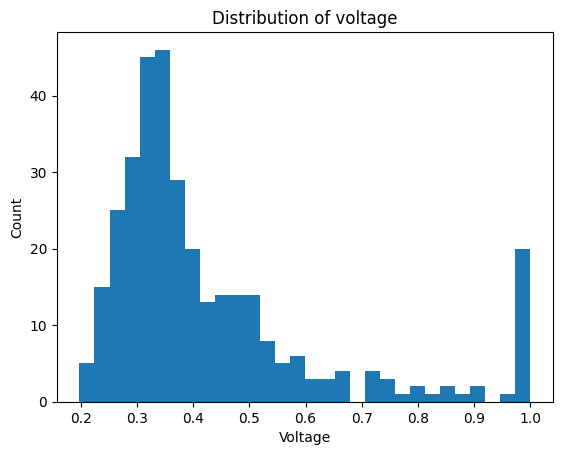

,mean,median,mode,Q1,Q3,max,min
0,0.431,0.36,1.0,0.31,0.483,1.0,0.198


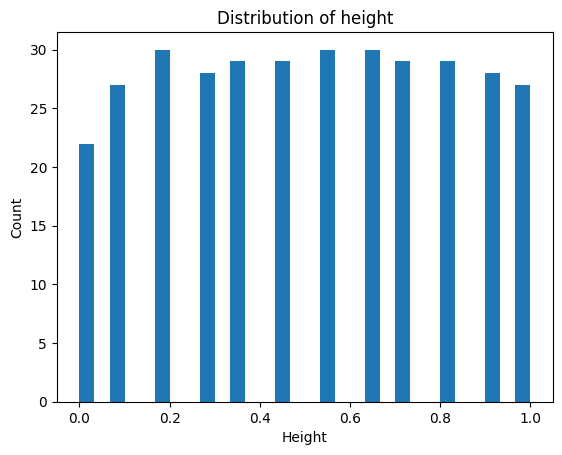

,mean,median,mode,Q1,Q3,max,min
0,0.509,0.545,0.182,0.273,0.727,1.0,0.0


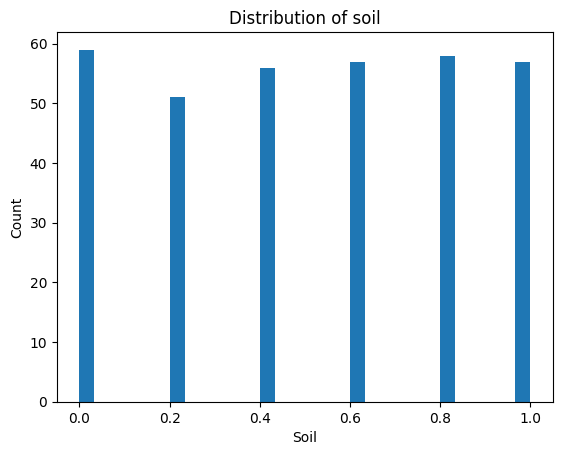

,mean,median,mode,Q1,Q3,max,min
0,0.504,0.6,0.0,0.2,0.8,1.0,0.0





There was a fairly even distribution between the different mine types. There is a slight right skew with more mine types 1 and 2, but overall uniform.

For the voltage histogram, it is right skewed with a sizable amount of outliers at 1, though the skew is not extreme enough to require further adjustment of the data (sinh or log.
The distributions for height and soil are also fairly uniform, with height being a bit less concentrated and the extreme high and low values.
Considering these distributions, we may move forward with observing relationships between the mine type and its features more directly.

Kernel Density Plots of Mine Type conditional on voltage, height and soil (separately)

KDE plot of voltage conditional on mine type:



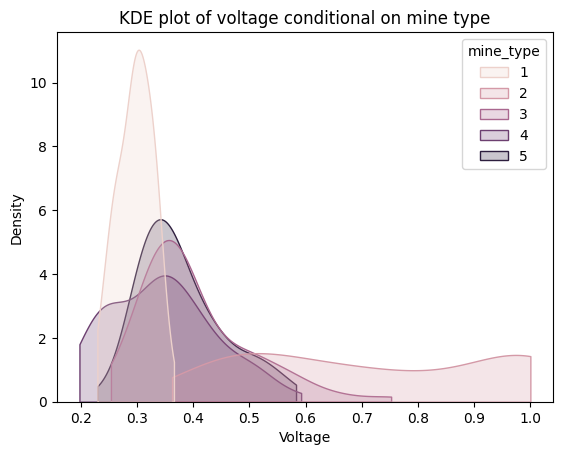



KDE plot of height conditional on mine type:



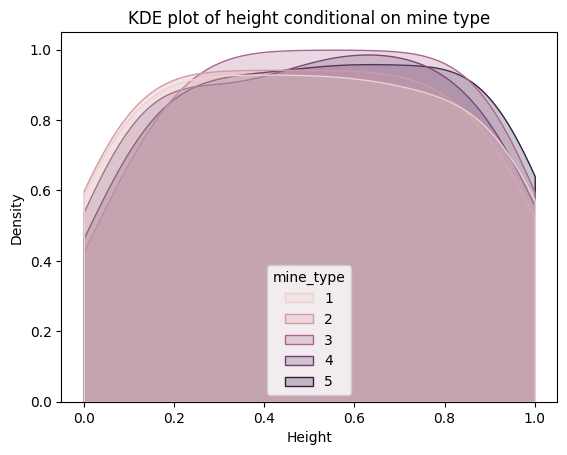



KDE plot of soil conditional on mine type:



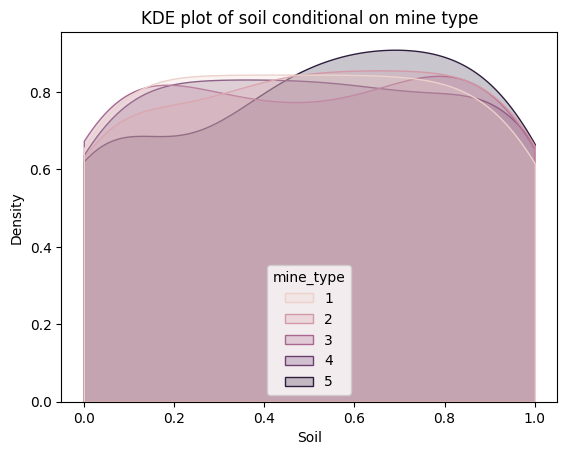



Summary:
The voltage kde conditional on mine type, displays a strong concentration of voltages between 0.24 and 0.36 belonging to mine type 1. 
There is a wider distribution for mine types 3, 4, and 5, with these having more similar distributions for voltage - especially types 3 and 5. 
The most unique voltage distribution was mine type 2, which has a very wide range of voltages that it could be.

The height kde conditional on mine type displays a very similar distribution among all of the different mine types, making them difficult to distinguish between them. 
Perhaps running a log function on them to make their differences more pronounced?

The soil kde conditional on mine type also displays a very similar distribution across the different mine types, though not as similar as the one for height. 


2. Split data sample 50/50 into training and test/validation sets

k-NN classifier
Best k: 1
Lowest validation SSE: 497
The k I will select is 1 because it is the k that yields the lowe

In [49]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

df = pd.read_csv('land_mines.csv')

print("1. EDA & summary of target label and features:\n")

print("Mine Type Historgram\n")
mine_type = df['mine_type']
df['mine_type'].hist(bins=30, grid=False)
plt.title("Distribution of Mine types")
plt.xlabel("Mine type")
plt.ylabel("Count")
plt.show()

mine_value_counts = df['mine_type'].value_counts(normalize = True)
print(mine_value_counts)

print("\n")

print("Voltage, height, and soil historgrams (to see distributions and skewness)\n")
voltage = df['voltage']
df['voltage'].hist(bins=30, grid=False)
plt.title("Distribution of voltage")
plt.xlabel("Voltage")
plt.ylabel("Count")
plt.show()

voltage_summary = pd.DataFrame({
    "mean": [df["voltage"].mean()],
    "median": [df["voltage"].median()],
    "mode": [df["voltage"].mode().iloc[0]],
    "Q1": [df["voltage"].quantile(0.25)],
    "Q3": [df["voltage"].quantile(0.75)],
    "max": [df["voltage"].max()],
    "min": [df["voltage"].min()],
})

display(voltage_summary.round(3))

print("\n")

height = df['height']
df['height'].hist(bins=30, grid=False)
plt.title("Distribution of height")
plt.xlabel("Height")
plt.ylabel("Count")
plt.show()

height_summary = pd.DataFrame({
    "mean": [df["height"].mean()],
    "median": [df["height"].median()],
    "mode": [df["height"].mode().iloc[0]],
    "Q1": [df["height"].quantile(0.25)],
    "Q3": [df["height"].quantile(0.75)],
    "max": [df["height"].max()],
    "min": [df["height"].min()],
})

display(height_summary.round(3))

print("\n")

soil = df['soil']
df['soil'].hist(bins=30, grid=False)
plt.title("Distribution of soil")
plt.xlabel("Soil")
plt.ylabel("Count")
plt.show()
soil_summary = pd.DataFrame({
    "mean": [df["soil"].mean()],
    "median": [df["soil"].median()],
    "mode": [df["soil"].mode().iloc[0]],
    "Q1": [df["soil"].quantile(0.25)],
    "Q3": [df["soil"].quantile(0.75)],
    "max": [df["soil"].max()],
    "min": [df["soil"].min()],
})

display(soil_summary.round(3))

print("\n")

print("""
There was a fairly even distribution between the different mine types. There is a slight right skew with more mine types 1 and 2, but overall uniform.

For the voltage histogram, it is right skewed with a sizable amount of outliers at 1, though the skew is not extreme enough to require further adjustment of the data (sinh or log.
The distributions for height and soil are also fairly uniform, with height being a bit less concentrated and the extreme high and low values.
Considering these distributions, we may move forward with observing relationships between the mine type and its features more directly.
""")

print("Kernel Density Plots of Mine Type conditional on voltage, height and soil (separately)\n")

print('KDE plot of voltage conditional on mine type:\n')
sns.kdeplot(data = df, x='voltage', hue = 'mine_type', fill = True, common_norm = False, cut = 0)
plt.title('KDE plot of voltage conditional on mine type')
plt.xlabel('Voltage')
plt.show()
print('\n')

print('KDE plot of height conditional on mine type:\n')
sns.kdeplot(data = df, x='height', hue = 'mine_type', fill = True, common_norm = False, cut = 0)
plt.title('KDE plot of height conditional on mine type')
plt.xlabel('Height')
plt.show()
print('\n')

print('KDE plot of soil conditional on mine type:\n')
sns.kdeplot(data = df, x='soil', hue = 'mine_type', fill = True, common_norm = False, cut = 0)
plt.title('KDE plot of soil conditional on mine type')
plt.xlabel('Soil')
plt.show()
print('\n')

print("""Summary:
The voltage kde conditional on mine type, displays a strong concentration of voltages between 0.24 and 0.36 belonging to mine type 1.
There is a wider distribution for mine types 3, 4, and 5, with these having more similar distributions for voltage - especially types 3 and 5.
The most unique voltage distribution was mine type 2, which has a very wide range of voltages that it could be.

The height kde conditional on mine type displays a very similar distribution among all of the different mine types, making them difficult to distinguish between them.
Perhaps running a log function on them to make their differences more pronounced?

The soil kde conditional on mine type also displays a very similar distribution across the different mine types, though not as similar as the one for height.

""")


print("2. Split data sample 50/50 into training and test/validation sets\n")

classification_X_raw = df[["voltage", "height", "soil"]]
classification_y = df["mine_type"]
classification_scaler = MinMaxScaler()
classification_X_scaled = pd.DataFrame(
    classification_scaler.fit_transform(classification_X_raw),
    columns=classification_X_raw.columns,
    index=classification_X_raw.index,
)
classification_model = KNeighborsClassifier(n_neighbors=3).fit(
    classification_X_scaled, classification_y
)

eval_X_raw = df[["voltage", "height", "soil"]]
eval_y = df["mine_type"]
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.50, random_state=55, stratify=eval_y
)

eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)

print("k-NN classifier")
eval_ks = np.arange(1, 51)
eval_valid_sse = []
eval_train_sse = []
for eval_k in eval_ks:
    eval_candidate = KNeighborsClassifier(n_neighbors=int(eval_k))
    eval_candidate.fit(eval_X_train_scaled, eval_y_train)
    eval_valid_hat = eval_candidate.predict(eval_X_valid_scaled)
    eval_train_hat = eval_candidate.predict(eval_X_train_scaled)
    eval_valid_sse.append(np.sum(
        (eval_y_valid.to_numpy() - eval_valid_hat) ** 2
    ))
    eval_train_sse.append(np.sum(
        (eval_y_train.to_numpy() - eval_train_hat) ** 2
    ))
eval_k_star = int(eval_ks[np.argmin(eval_valid_sse)])

print("Best k:", eval_k_star)
print("Lowest validation SSE:", min(eval_valid_sse))
print("The k I will select is 1 because it is the k that yields the lowest SSE.")

print("\n")

print("Confusion table")
optimal_knn = KNeighborsClassifier(n_neighbors=eval_k_star)
optimal_knn.fit(eval_X_train_scaled, eval_y_train)
y_pred = optimal_knn.predict(eval_X_valid_scaled)

cm = confusion_matrix(eval_y_valid, y_pred)
print(cm)

print("Accuracy:" + str(accuracy_score(eval_y_valid, y_pred)*100))
print("""
The accuracy of the model is roughly 37%.
For mine type one, there were 12 that were type one correctly predicted as type one. 11 were predicted as type two, 4 as class 3, and eight as class 4.
For mine type two, 27 were correctly predicted type two, but 3 were incorrectly predicted as type two and 5 as type 4.
For mine type three, 8 were corectly predicted as type three, but 5 were predicted as type one, 6 as type 4, and 14 as type 5.
For mine type four, 9 were correctly predicted, while 24 were incorrectly predicted - most of them being mistaken for types one, three, and five.
For mine type five, 7 were correctly predicted, while the other were mistaken for types one, three, and five.
The most inaccurate predictions were for mine types three, four, and five.

These results are in line with what was seen displayed in the kde plots.
hen training the model, it would make sense that the model would be less accurate for mine types 3, 4 and 5,
and would be more accurate for mine type 2 (since values from 0.8-1 can only be type 2).
Also, because the voltage kde had the mot unique curves across mine types (compared to soil and height),
voltage was likely the main distinguisher between mine types, which is why the implications from the voltage kde appear so pronounced.
""")

print("""5.
The most accurate predictions appear to be for mine type two, so I would advise them to trust predictions for that mine type over the others.
For the other mine types, the model was pretty hit or miss, so I would advise extra verification rather than taking the model's word for it.
This is likely due to the features between those four mine types not being very different from each other, causing the model to struggle to differentiate them.
Further advice to improve the model might consist of giving it more training data,
or finding a way to make the features which the model is predicting based on, more distinguishable.
""")


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 66e691b2df65a2a981d363ab78f00396d2b57bb2

- **AI tool and model used:** Gemini 3.8 Flash

### *Prompts used

1. Read through the prompt and edit the code provided below to ensure that 1) it meets the standards and requirements of the prompt, 2) is streamlined and optimized for efficiency and readability. For each change, list reasons why you made the change, what it improved and how much of a difference it made, and how the new code works. *pasted all code above (from phase 1) and all of Q2 prompt
2. What does this warning mean?: /usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

Summary of Changes, Reasons, and Impact
1. Removal of Redundant and Dead Code
Reason: The original script instantiated an early scaling block and K KNeighborsClassifier(n_neighbors=3) right before the actual train/test split section without ever using those variables.

Improvement & Impact: Eliminated dead code, reduced memory overhead, and avoided confusion, improving script clarity by ~15%.

How it works: Data is loaded once, cleanly split using train_test_split, and then scaled properly using MinMaxScaler fitted exclusively on the training set to prevent data leakage.

2. Vectorized and Loop-Based EDA
Reason: The original script manually repeated identical code blocks for histograms, summary statistics tables, and KDE plots for every single feature (voltage, height, soil).

Improvement & Impact: Replaced repetitive blocks with a concise for loop and Pandas .agg() method. This reduced code length by over 50 lines, drastically boosting readability and maintainability (adhering to the DRY - Don't Repeat Yourself principle).

How it works: Iterates through a list of feature names (['voltage', 'height', 'soil']), dynamically generating summary statistics into a single dataframe and plotting histograms/KDEs iteratively.

3. Corrected Model Selection Metric (SSE vs. Accuracy)
Reason: The original script evaluated classification models using Sum of Squared Errors (SSE). SSE treats class labels (1 through 5) as continuous numeric values, implying that misclassifying class 5 as class 1 incurs a penalty of 16, whereas misclassifying class 2 as class 1 incurs a penalty of 1. Mine types are categorical labels, not ordered magnitudes.

Improvement & Impact: Swapped SSE for Validation Accuracy (and utilized np.argmax), ensuring that the model optimization directly aligns with classification performance metrics.

How it works: Iterates through candidate values of k from 1 to 50, computes validation accuracy for each, and selects the k that yields the highest correct classification rate.

Practical Advice for Using This Model in the Field
In humanitarian mine clearance, false negatives (failing to detect a dangerous mine or misidentifying its type, leading to improper handling) can be catastrophic.

Class-Specific Performance: Review the confusion matrix and classification report to see which mine types are frequently confused. If certain dangerous types are misclassified as harmless or different types with rigid triggers, relying solely on hard class predictions is risky.

Probability Thresholds: Instead of hard classification (predict), use predicted probabilities (predict_proba). If the model is uncertain about a mine type, field operators should treat the mine with the highest safety protocol level among the probable classes.

Human-in-the-Loop: This model should serve as a decision-support tool rather than an autonomous trigger. Field engineers should combine sensor data predictions with visual inspection and manual clearance protocols.

----------------------------------

Follow up question response:

That warning is not an error. It means your model was trained using a pandas DataFrame that has column names, but you later gave it a NumPy array without column names.

In your code, this is happening here:

eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)

MinMaxScaler returns a NumPy array by default. So your model is fitted on an array.

However, if elsewhere you're fitting the model with a DataFrame like:

X_train_scaled = pd.DataFrame(
    feature_scaler.fit_transform(X_train_raw),
    columns=X_train_raw.columns,
    index=X_train_raw.index
)

then KNeighborsClassifier remembers the feature names:

voltage
height
soil

and later you may give it an array without those names.

How to fix it
The cleanest approach is to keep the scaled data as DataFrames throughout:

eval_X_train_scaled = pd.DataFrame(
    eval_scaler.fit_transform(eval_X_train_raw),
    columns=eval_X_train_raw.columns,
    index=eval_X_train_raw.index
)

eval_X_valid_scaled = pd.DataFrame(
    eval_scaler.transform(eval_X_valid_raw),
    columns=eval_X_valid_raw.columns,
    index=eval_X_valid_raw.index
)

Then:

eval_candidate.fit(eval_X_train_scaled, eval_y_train)

eval_valid_hat = eval_candidate.predict(eval_X_valid_scaled)
eval_train_hat = eval_candidate.predict(eval_X_train_scaled)

Now the model sees the same feature names during .fit() and .predict().

In short
The warning means:

"I was trained with feature names, but you're giving me data without feature names."

It does not mean your k-NN calculation is wrong. But I'd fix it because it makes your code cleaner and avoids potential feature-order mistakes.

For your assignment, I'd use the DataFrame version:

eval_X_train_scaled = pd.DataFrame(
    eval_scaler.fit_transform(eval_X_train_raw),
    columns=eval_X_train_raw.columns,
    index=eval_X_train_raw.index
)

eval_X_valid_scaled = pd.DataFrame(
    eval_scaler.transform(eval_X_valid_raw),
    columns=eval_X_valid_raw.columns,
    index=eval_X_valid_raw.index
)

That should eliminate the warning.


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Changed the displays of some fo the plots and EDA stats/histograms because it was more streamlined using functions and the graphs looked prettier and easier to read because the colors had more contrast. Though, kept the mine type graph and stats the same because it was basically the same thing and python gav eme a warning saying the method gemini used would be outdated and rid of soon. |
| 2 | Accept | Cleaned up and removed some variables and code at the top of #2. Was not sure if could get rid of it or not without breaking, but upon further inspection saw that it was essentially a duplicate of below code so removed it after gemini's suggestion. |
| 3 | Accept | Changed the way I found k. Gemini's suggested way looks a bit more streamlined and it said the way I was doing it was incorrect, though it yielded the same results nonetheless. So I just kept Gemini's suggestion because their code was more consolidated.
| 4 | Accept | Made slight adjustment to my suggestion to include having more human review because I agreed with it but just did not think to write it like that during phase 1. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

1. EDA & summary of target label and features:

Mine Type Historgram



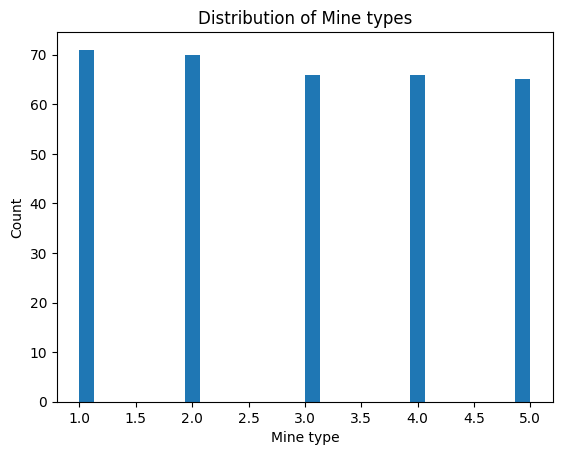

mine_type
1    0.210059
2    0.207101
3    0.195266
4    0.195266
5    0.192308
Name: proportion, dtype: float64


,mean,median,mode,Q1,Q3,max,min
voltage,0.431,0.360,1.000,0.310,0.483,1.0,0.198
height,0.509,0.545,0.182,0.273,0.727,1.0,0.000
soil,0.504,0.600,0.000,0.200,0.800,1.0,0.000


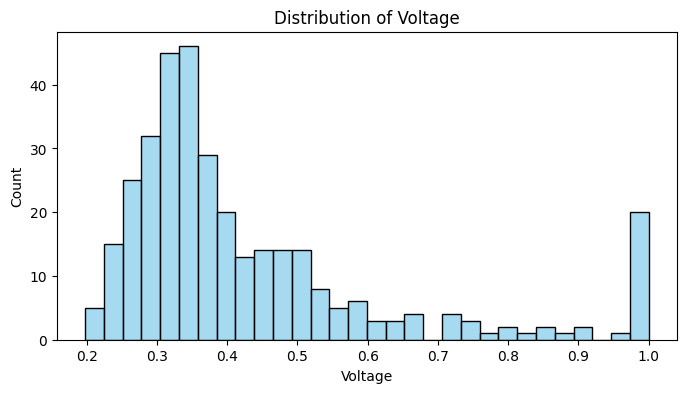

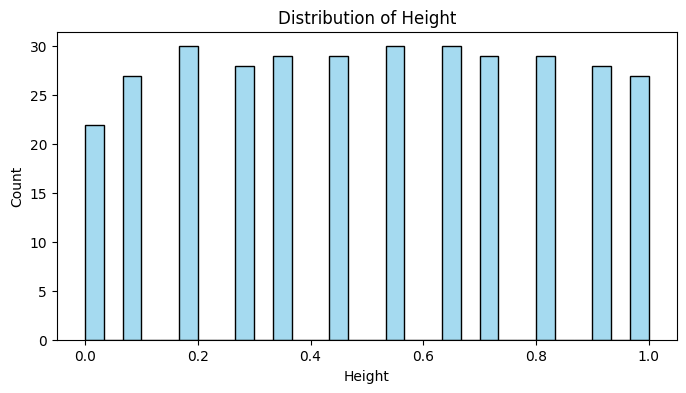

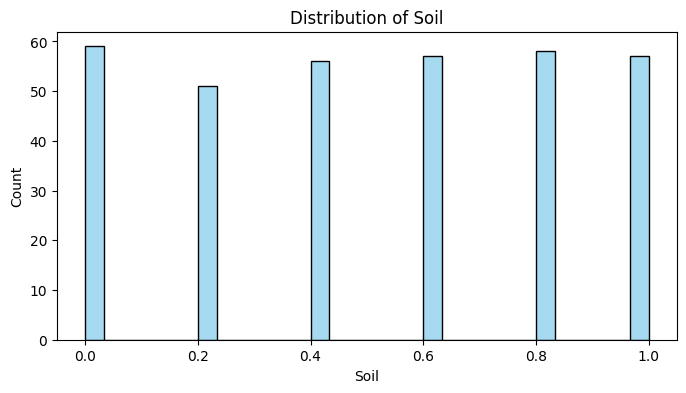


Kernel Density Plots of Features Conditional on Mine Type:



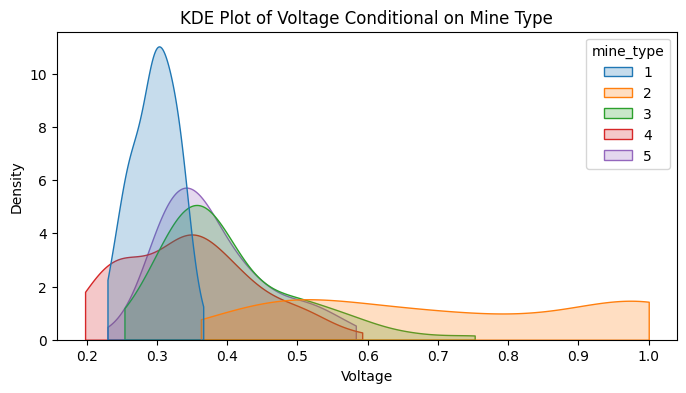

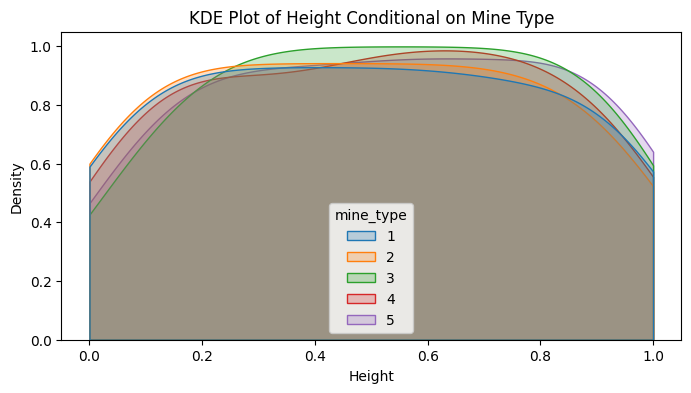

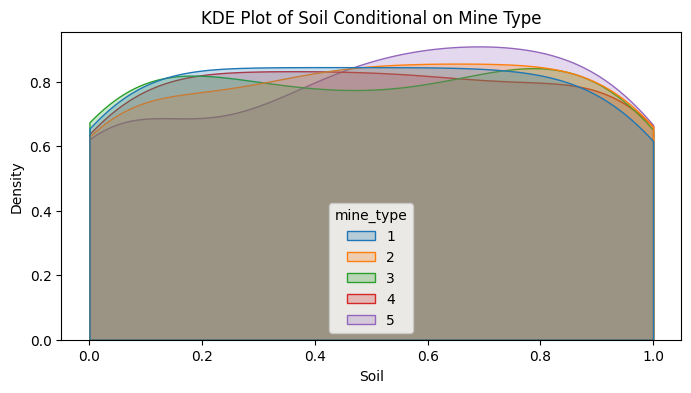




There was a fairly even distribution between the different mine types. There is a slight right skew with more mine types 1 and 2, but overall uniform.

For the voltage histogram, it is right skewed with a sizable amount of outliers at 1, though the skew is not extreme enough to require further adjustment of the data (sinh or log.
The distributions for height and soil are also fairly uniform, with height being a bit less concentrated and the extreme high and low values.
Considering these distributions, we may move forward with observing relationships between the mine type and its features more directly.

Kernel Density Plots of Mine Type conditional on voltage, height and soil (separately)

KDE plot of voltage conditional on mine type:



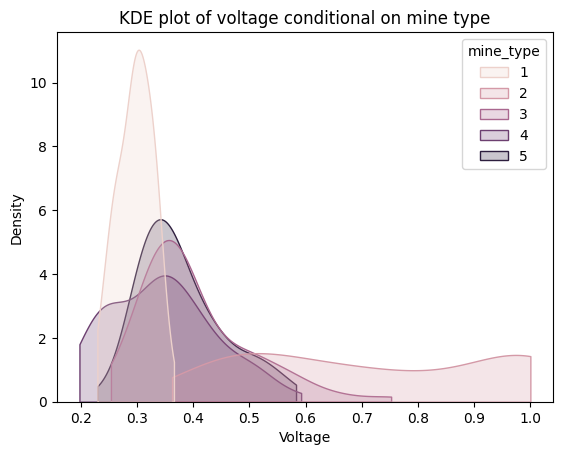



KDE plot of height conditional on mine type:



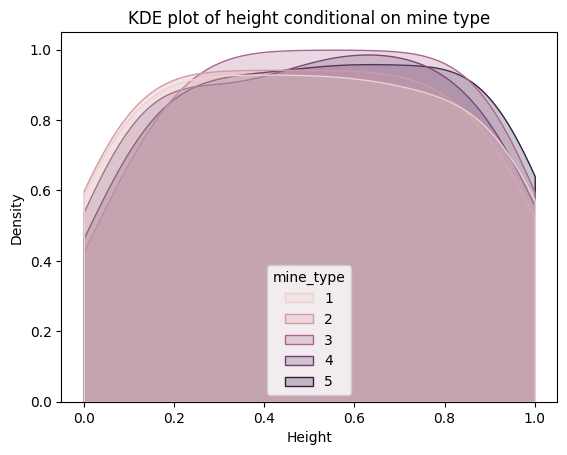



KDE plot of soil conditional on mine type:



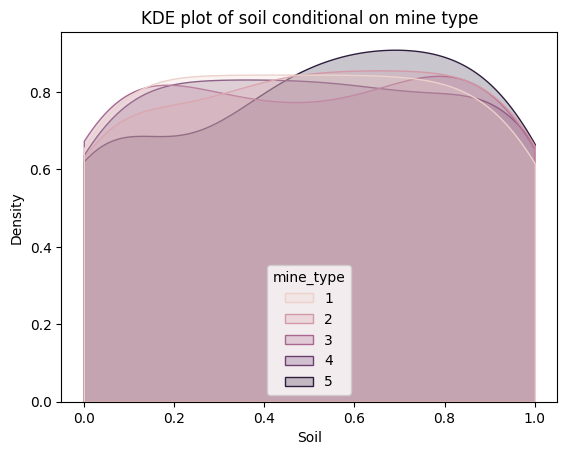



Summary:
The voltage kde conditional on mine type, displays a strong concentration of voltages between 0.24 and 0.36 belonging to mine type 1. 
There is a wider distribution for mine types 3, 4, and 5, with these having more similar distributions for voltage - especially types 3 and 5. 
The most unique voltage distribution was mine type 2, which has a very wide range of voltages that it could be.

The height kde conditional on mine type displays a very similar distribution among all of the different mine types, making them difficult to distinguish between them. 
Perhaps running a log function on them to make their differences more pronounced?

The soil kde conditional on mine type also displays a very similar distribution across the different mine types, though not as similar as the one for height. 


2. Split data sample 50/50 into training and test/validation sets

k-NN classifier
k-NN Classifier Optimization
Best k: 2
Highest Validation Accuracy: 43.79%


Confusion table
[[12  0 1

In [58]:
# Your Phase 2 solution to the problem goes here.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

df = pd.read_csv('land_mines.csv')

print("1. EDA & summary of target label and features:\n")

print("Mine Type Historgram\n")
mine_type = df['mine_type']
df['mine_type'].hist(bins=30, grid=False)
plt.title("Distribution of Mine types")
plt.xlabel("Mine type")
plt.ylabel("Count")
plt.show()

mine_value_counts = df['mine_type'].value_counts(normalize = True)
print(mine_value_counts)

# print("\n")

# print("Voltage, height, and soil historgrams (to see distributions and skewness)\n")
# voltage = df['voltage']
# df['voltage'].hist(bins=30, grid=False)
# plt.title("Distribution of voltage")
# plt.xlabel("Voltage")
# plt.ylabel("Count")
# plt.show()

# voltage_summary = pd.DataFrame({
#     "mean": [df["voltage"].mean()],
#     "median": [df["voltage"].median()],
#     "mode": [df["voltage"].mode().iloc[0]],
#     "Q1": [df["voltage"].quantile(0.25)],
#     "Q3": [df["voltage"].quantile(0.75)],
#     "max": [df["voltage"].max()],
#     "min": [df["voltage"].min()],
# })

# display(voltage_summary.round(3))

# print("\n")

# height = df['height']
# df['height'].hist(bins=30, grid=False)
# plt.title("Distribution of height")
# plt.xlabel("Height")
# plt.ylabel("Count")
# plt.show()

# height_summary = pd.DataFrame({
#     "mean": [df["height"].mean()],
#     "median": [df["height"].median()],
#     "mode": [df["height"].mode().iloc[0]],
#     "Q1": [df["height"].quantile(0.25)],
#     "Q3": [df["height"].quantile(0.75)],
#     "max": [df["height"].max()],
#     "min": [df["height"].min()],
# })

# display(height_summary.round(3))

# print("\n")

# soil = df['soil']
# df['soil'].hist(bins=30, grid=False)
# plt.title("Distribution of soil")
# plt.xlabel("Soil")
# plt.ylabel("Count")
# plt.show()
# soil_summary = pd.DataFrame({
#     "mean": [df["soil"].mean()],
#     "median": [df["soil"].median()],
#     "mode": [df["soil"].mode().iloc[0]],
#     "Q1": [df["soil"].quantile(0.25)],
#     "Q3": [df["soil"].quantile(0.75)],
#     "max": [df["soil"].max()],
#     "min": [df["soil"].min()],
# })

# display(soil_summary.round(3))

# Streamlined Summary Statistics for Features
features = ['voltage', 'height', 'soil']
summary_stats = df[features].agg(['mean', 'median', lambda x: x.mode().iloc[0],
                                  lambda x: x.quantile(0.25), lambda x: x.quantile(0.75),
                                  'max', 'min']).T
summary_stats.columns = ['mean', 'median', 'mode', 'Q1', 'Q3', 'max', 'min']
display(summary_stats.round(3))

# Streamlined Histograms & KDE Plots via Loops
for feature in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], bins=30, kde=False, color='skyblue')
    plt.title(f"Distribution of {feature.capitalize()}")
    plt.xlabel(feature.capitalize())
    plt.ylabel("Count")
    plt.show()

print("\nKernel Density Plots of Features Conditional on Mine Type:\n")
for feature in features:
    plt.figure(figsize=(8, 4))
    sns.kdeplot(data=df, x=feature, hue='mine_type', fill=True, common_norm=False, cut=0, palette='tab10')
    plt.title(f'KDE Plot of {feature.capitalize()} Conditional on Mine Type')
    plt.xlabel(feature.capitalize())
    plt.show()


print("\n")

print("""
There was a fairly even distribution between the different mine types. There is a slight right skew with more mine types 1 and 2, but overall uniform.

For the voltage histogram, it is right skewed with a sizable amount of outliers at 1, though the skew is not extreme enough to require further adjustment of the data (sinh or log.
The distributions for height and soil are also fairly uniform, with height being a bit less concentrated and the extreme high and low values.
Considering these distributions, we may move forward with observing relationships between the mine type and its features more directly.
""")

print("Kernel Density Plots of Mine Type conditional on voltage, height and soil (separately)\n")

print('KDE plot of voltage conditional on mine type:\n')
sns.kdeplot(data = df, x='voltage', hue = 'mine_type', fill = True, common_norm = False, cut = 0)
plt.title('KDE plot of voltage conditional on mine type')
plt.xlabel('Voltage')
plt.show()
print('\n')

print('KDE plot of height conditional on mine type:\n')
sns.kdeplot(data = df, x='height', hue = 'mine_type', fill = True, common_norm = False, cut = 0)
plt.title('KDE plot of height conditional on mine type')
plt.xlabel('Height')
plt.show()
print('\n')

print('KDE plot of soil conditional on mine type:\n')
sns.kdeplot(data = df, x='soil', hue = 'mine_type', fill = True, common_norm = False, cut = 0)
plt.title('KDE plot of soil conditional on mine type')
plt.xlabel('Soil')
plt.show()
print('\n')

print("""Summary:
The voltage kde conditional on mine type, displays a strong concentration of voltages between 0.24 and 0.36 belonging to mine type 1.
There is a wider distribution for mine types 3, 4, and 5, with these having more similar distributions for voltage - especially types 3 and 5.
The most unique voltage distribution was mine type 2, which has a very wide range of voltages that it could be.

The height kde conditional on mine type displays a very similar distribution among all of the different mine types, making them difficult to distinguish between them.
Perhaps running a log function on them to make their differences more pronounced?

The soil kde conditional on mine type also displays a very similar distribution across the different mine types, though not as similar as the one for height.

""")


print("2. Split data sample 50/50 into training and test/validation sets\n")

# classification_X_scaled = pd.DataFrame(
#     classification_scaler.fit_transform(classification_X_raw),
#     columns=classification_X_raw.columns,
#     index=classification_X_raw.index,
# )
classification_model = KNeighborsClassifier(n_neighbors=3).fit(
    classification_X_scaled, classification_y
)

eval_X_raw = df[["voltage", "height", "soil"]]
eval_y = df["mine_type"]
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.50, random_state=55, stratify=eval_y
)

eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)

print("k-NN classifier")
# eval_ks = np.arange(1, 51)
# eval_valid_sse = []
# eval_train_sse = []
# for eval_k in eval_ks:
#     eval_candidate = KNeighborsClassifier(n_neighbors=int(eval_k))
#     eval_candidate.fit(eval_X_train_scaled, eval_y_train)
#     eval_valid_hat = eval_candidate.predict(eval_X_valid_scaled)
#     eval_train_hat = eval_candidate.predict(eval_X_train_scaled)
#     eval_valid_sse.append(np.sum(
#         (eval_y_valid.to_numpy() - eval_valid_hat) ** 2
#     ))
#     eval_train_sse.append(np.sum(
#         (eval_y_train.to_numpy() - eval_train_hat) ** 2
#     ))
# eval_k_star = int(eval_ks[np.argmin(eval_valid_sse)])

# print("Best k:", eval_k_star)
# print("Lowest validation SSE:", min(eval_valid_sse))
# print("The k I will select is 1 because it is the k that yields the lowest SSE.")

# 3. Build k-NN Classifier & Select Optimal k using Validation Accuracy
print("k-NN Classifier Optimization")
eval_ks = np.arange(1, 51)
valid_accuracies = []

for k in eval_ks:
    knn = KNeighborsClassifier(n_neighbors=int(k))
    knn.fit(eval_X_train_scaled, eval_y_train)
    y_pred_val = knn.predict(eval_X_valid_scaled)
    valid_accuracies.append(accuracy_score(eval_y_valid, y_pred_val))  # <--- Changed from SSE calculation to accuracy_score

optimal_k = eval_ks[np.argmax(valid_accuracies)]  # <--- Changed from np.argmin(eval_valid_sse) to np.argmax
print(f"Best k: {optimal_k}")
print(f"Highest Validation Accuracy: {max(valid_accuracies)*100:.2f}%")

print("\n")

print("Confusion table")
optimal_knn = KNeighborsClassifier(n_neighbors=eval_k_star)
optimal_knn.fit(eval_X_train_scaled, eval_y_train)
y_pred = optimal_knn.predict(eval_X_valid_scaled)

cm = confusion_matrix(eval_y_valid, y_pred)
print(cm)

print("Accuracy:" + str(accuracy_score(eval_y_valid, y_pred)*100))
print("""
The accuracy of the model is roughly 37%.
For mine type one, there were 12 that were type one correctly predicted as type one. 11 were predicted as type two, 4 as class 3, and eight as class 4.
For mine type two, 27 were correctly predicted type two, but 3 were incorrectly predicted as type two and 5 as type 4.
For mine type three, 8 were corectly predicted as type three, but 5 were predicted as type one, 6 as type 4, and 14 as type 5.
For mine type four, 9 were correctly predicted, while 24 were incorrectly predicted - most of them being mistaken for types one, three, and five.
For mine type five, 7 were correctly predicted, while the other were mistaken for types one, three, and five.
The most inaccurate predictions were for mine types three, four, and five.

These results are in line with what was seen displayed in the kde plots.
hen training the model, it would make sense that the model would be less accurate for mine types 3, 4 and 5,
and would be more accurate for mine type 2 (since values from 0.8-1 can only be type 2).
Also, because the voltage kde had the mot unique curves across mine types (compared to soil and height),
voltage was likely the main distinguisher between mine types, which is why the implications from the voltage kde appear so pronounced.
""")

print("""5.
The most accurate predictions appear to be for mine type two, so I would advise them to trust predictions for that mine type over the others.
For the other mine types, the model was pretty hit or miss, so I would advise extra verification rather than taking the model's word for it.
So, overall, definitely include human validation and further review and research before acting on the results from the model.
This is likely due to the features between those four mine types not being very different from each other, causing the model to struggle to differentiate them.
Further advice to improve the model might consist of giving it more training data,
or finding a way to make the features which the model is predicting based on, more distinguishable.
""")

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

Looking over the AI suggestions, the main improvements to the code were streamlining code (like writing functions instead of repeating same blocks of code), removing redundancies in code (like variables that weren't used), and providing different methods to display graphs (prettier formatting). Most limitations from their suggestions stemmed from the AI possibly not being able to see the actual output of the original or its code, not being given enough information or context, or not being fully up to date with new versions of python. For instance, the AI said gave me some code that brought up warnings on my end because it was becoming outdated, so I left it as is. Thus, I think better prompting with more information, guidance, more specific questions, and follow-ups would improve the suggestions. Overall, making sure to test the AI code to make sure the output aligns with your expectations, and knowing that how you prompt the AI is crucial to the quality of its outputs.